## Задание 1

In [12]:
def gauss_2(a, b):
    """Return nodes and weights for a two-point Gauss quadrature on [a, b]."""
    x1_ref, x2_ref = -1 / (3**0.5), 1 / (3**0.5)  # Узлы в [-1, 1]
    w1, w2 = 1., 1.  # Веса
    x1 = 0.5 * ((b + a) + (b - a) * x1_ref)  # Преобразование в [a, b]
    x2 = 0.5 * ((b + a) + (b - a) * x2_ref)
    return x1, x2, w1, w2

# Тестирование
from numpy.testing import assert_allclose

x1, x2, w1, w2 = gauss_2(0, 1)

def f(x, n): 
    return x**n

for n in [0, 1, 2, 3]:
    assert_allclose(
        0.5 * (w1*f(x1, n=n) + w2*f(x2, n=n)),  # Вычисленный интеграл
        1./(n+1),  # Точное значение
        atol=1e-14
    )

print("тесты пройдены! Функция работает правильно.")


тесты пройдены! Функция работает правильно.


## Задание 2

In [13]:
import numpy as np
from math import pi, e, sqrt, exp

def integ(npts=50):
    """Вычисление интеграла методом трапеций с вычитанием сингулярности.

    Интеграл разлагается на аналитическую часть и численный остаток.
    
    Параметры
    ----------
    npts : int
        Количество точек для метода трапеций.
        
    Возвращает
    -------
    I : float
        Вычисленное значение интеграла.
    """
    I_sing = pi * (1 + (e - 1) / 2)
    x = np.linspace(0, 1, npts)
    R = np.exp(x) - (1 + (e - 1) * x)
    denom = np.sqrt(x * (1 - x))
    denom[0] = denom[-1] = 1  
    f = R / denom
    f[0] = f[-1] = 0  
    h = 1 / (npts - 1)
    I_rem = h * (0.5 * f[0] + np.sum(f[1:-1]) + 0.5 * f[-1])

    return I_sing + I_rem

I = integ(npts=50)

print(f"Вычисленное значение интеграла I = {I:.12f}")

Вычисленное значение интеграла I = 5.509469677731


## Задание 4


## Условие
Требуется вычислить интеграл:

\[
J = \int_{0.5}^{-0.5} |x|^{-2} \cdot (1-x)^{-1} \, dx
\]

с учетом особенностей.

### Вычитание сингулярности
Для точности расчётов необходимо учесть особенности в нуле. В нашем случае интеграл ведёт себя как:

$
|x|^{-1/2}
$

Если имеем требуемую точность \( \epsilon \), возьмем:

$
\delta_1 = \delta_2 = \delta
$

Тогда:

$
I_0 = \int_{\delta}^{0.5} |x|^{-1/2} \, dx = 4\sqrt{\delta} < \epsilon
$

Отсюда получаем:
$
\delta < \frac{\epsilon^2}{16}
$


## Задание 5

In [3]:
import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt
import sympy as smp
from sympy.polys.polyfuncs import interpolate
from scipy.special import roots_chebyt

In [4]:
x = np.linspace(0, np.pi, 100)
f = lambda x, k: np.exp(-x) * np.sin(k*x)
ks = [1, 5, 10, 25, 50, 75, 100, 200, 300, 400, 500, 1000]
right_ans = lambda k: k / (1 + k**2) - np.exp(-np.pi) * (k*np.cos(k*np.pi) + np.sin(k*np.pi)) / (1+k**2) 

In [5]:
simpson_errors = []
for k in ks:
    simpson_errors.append(abs((integrate.simpson(f(x, k), x=x) - right_ans(k)) / right_ans(k)))

In [6]:
t = smp.Symbol('t')
n = 10
nodes, _ = roots_chebyt(n)
nodes = nodes*np.pi/2 + np.pi/2
points = np.exp(-nodes)

exp_interp = interpolate(points, t)

In [7]:
interpolation_errors = []
for k in ks:
    part_integral = np.float64(smp.integrate(exp_interp * smp.sin(k * t), (t, 0, smp.pi)).evalf())
    integral = integrate.simpson((np.exp(-x) - smp.lambdify(t, exp_interp, 'numpy')(x)) * np.sin(k*x) , x=x) + part_integral
    interpolation_errors.append(abs((integral - right_ans(k)) / right_ans(k)))
    print(part_integral, integral - part_integral)
interpolation_errors

1.7837105631631454 -1.2621036515355237
0.3222760644212276 -0.1216615271240846
0.041347005867439265 0.053410534954323644
0.06456773727033427 -0.023231564092680304
0.008280650112554211 0.011393938995341765
0.021524462131341907 -0.002087313079898692
0.0041405235108203115 0.4202645956804692
0.0020702866701809925 0.16286255856995044
0.0013801941925113415 0.07335463563297345
0.0010351464528110229 0.1219253967543006
0.000828117461622551 0.0383796672840792
0.0004140589304058569 0.053410534954331304


[9.107291168259829e-08,
 1.7565255129329554e-05,
 0.0002770531142097961,
 0.00781828324232033,
 0.02857155425079161,
 0.3976475153554584,
 43.361803312709846,
 33.47729261737593,
 22.43334470654008,
 50.40597843454221,
 19.48939795700843,
 55.255675889074794]

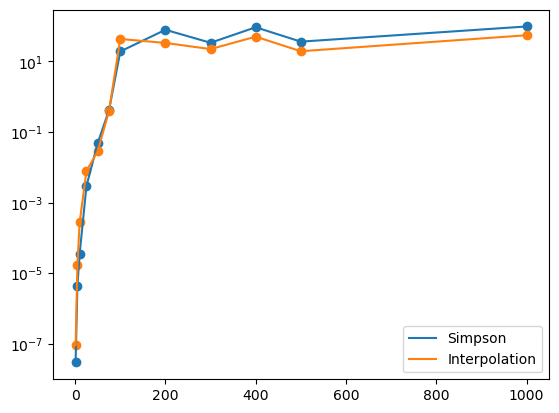

In [8]:
plt.semilogy(ks, simpson_errors, label="Simpson")
plt.scatter(ks, simpson_errors)
plt.semilogy(ks, interpolation_errors, label="Interpolation")
plt.scatter(ks, interpolation_errors)
plt.legend()
plt.show()

## Задание 6

Сделаем замену переменных:

$\int _0 ^1 \frac{cos(2 \pi t)}{\sqrt{1 - t^2}} dt = \frac{1}{2} \int _{-1} ^1 \frac{cos(2 \pi t)}{\sqrt{1 - t^2}} dt$

Интеграл в правой части можно посчитать, используя полиномы Чебышева 1-ого рода, что мы и сделаем.

In [9]:
x = smp.Symbol('x')
original_func = smp.cos(x) / (4 * smp.pi**2 - x**2)**0.5
right_ans = float(smp.integrate(original_func, (x, 0, 2*smp.pi)).evalf())

In [10]:
MIN_ERROR = 1e-16
error = 1
n = 2
f = lambda t: np.cos(2 * np.pi * t) 

while(error >= MIN_ERROR):
    nodes, w = roots_chebyt(n)
    integral = 0.5 * (w *f(nodes)).sum()
    error = abs(integral - right_ans)
    print(f"n: {n}, ans: {integral}, error: {error}")
    n += 1

n: 2, ans: -0.4182329132681745, error: 0.764243072080439
n: 3, ans: 1.2211694475711936, error: 0.8751592887589292
n: 4, ans: 0.11575359323141321, error: 0.23025656558085122
n: 5, ans: 0.37786106634872507, error: 0.03185090753646064
n: 6, ans: 0.34323498164389277, error: 0.0027751771683716675
n: 7, ans: 0.34617799427660145, error: 0.00016783546433701835
n: 8, ans: 0.34600266762714144, error: 7.491185122998623e-06
n: 9, ans: 0.3460104163733289, error: 2.575610644761639e-07
n: 10, ans: 0.3460101517706765, error: 7.04158792386167e-09
n: 11, ans: 0.3460101589691608, error: 1.5689638477311973e-10
n: 12, ans: 0.3460101588093585, error: 2.905953255805116e-12
n: 13, ans: 0.3460101588123096, error: 4.518607710224387e-14
n: 14, ans: 0.34601015881226377, error: 6.661338147750939e-16
n: 15, ans: 0.34601015881226416, error: 2.7755575615628914e-16
n: 16, ans: 0.34601015881226443, error: 0.0
